In [52]:
# import requests
# import pandas as pd

# url = "https://api.census.gov/data/2023/acs/acs5/profile?get=NAME,GEO_ID,DP02_0015PE,DP02_0072PE,DP02_0022PE,DP04_0058PE,DP05_0001E&for=tract:*&in=state:06"

# response = requests.get(url)
# data = response.json()

# # First row is the header
# df = pd.DataFrame(data[1:], columns=data[0])
# df.to_csv('CA Census Tract Demographic Info.csv', index=False)
# print(f'Saved {len(df):,} rows')

# Wildfire Evacuation Community Resource Matching — Census Tract Flag Analysis

This notebook processes California census tract demographic data and produces a clean output file
where each tract is annotated with:
- Per-county **Q3 threshold-based flags** indicating areas of elevated demographic need
- A preparedness tier based on total flag count

**Downstream handoffs:**
1. **Web map** (friend A) — consumes the GeoJSON for tract-level visualization and community resource matching
2. **LLM pipeline** (friend B) — consumes the CSV flag profiles to classify helper offers and match them to tracts in need


## 1. Imports

In [55]:
# import geopandas as gpd
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.colors as mcolors
# import warnings
# warnings.filterwarnings('ignore')

# pd.set_option('display.max_columns', 50)
# pd.set_option('display.float_format', '{:.2f}'.format)


## 2. File Paths & County Lookup

In [57]:
# File paths
# census_demo_path = 'CA Census Tract Demographic Info.csv'
# tracts_path      = 'data/tl_2025_06_tract/tl_2025_06_tract.shp'

census_demo_path = '/Users/simranmallik_1/Desktop/Grad School Courses/WiDS Project/CA Census Tract Demographic Info.csv'
tracts_path      = '/Users/simranmallik_1/Desktop/Grad School Courses/WiDS Project/tl_2025_06_tract/tl_2025_06_tract.shp'

# CA County FIPS -> display name + OSM place string
CA_COUNTIES = {
    '001': ('Alameda',        'Alameda County, California, USA'),
    '003': ('Alpine',         'Alpine County, California, USA'),
    '005': ('Amador',         'Amador County, California, USA'),
    '007': ('Butte',          'Butte County, California, USA'),
    '009': ('Calaveras',      'Calaveras County, California, USA'),
    '011': ('Colusa',         'Colusa County, California, USA'),
    '013': ('Contra Costa',   'Contra Costa County, California, USA'),
    '015': ('Del Norte',      'Del Norte County, California, USA'),
    '017': ('El Dorado',      'El Dorado County, California, USA'),
    '019': ('Fresno',         'Fresno County, California, USA'),
    '021': ('Glenn',          'Glenn County, California, USA'),
    '023': ('Humboldt',       'Humboldt County, California, USA'),
    '025': ('Imperial',       'Imperial County, California, USA'),
    '027': ('Inyo',           'Inyo County, California, USA'),
    '029': ('Kern',           'Kern County, California, USA'),
    '031': ('Kings',          'Kings County, California, USA'),
    '033': ('Lake',           'Lake County, California, USA'),
    '035': ('Lassen',         'Lassen County, California, USA'),
    '037': ('Los Angeles',    'Los Angeles County, California, USA'),
    '039': ('Madera',         'Madera County, California, USA'),
    '041': ('Marin',          'Marin County, California, USA'),
    '043': ('Mariposa',       'Mariposa County, California, USA'),
    '045': ('Mendocino',      'Mendocino County, California, USA'),
    '047': ('Merced',         'Merced County, California, USA'),
    '049': ('Modoc',          'Modoc County, California, USA'),
    '051': ('Mono',           'Mono County, California, USA'),
    '053': ('Monterey',       'Monterey County, California, USA'),
    '055': ('Napa',           'Napa County, California, USA'),
    '057': ('Nevada',         'Nevada County, California, USA'),
    '059': ('Orange',         'Orange County, California, USA'),
    '061': ('Placer',         'Placer County, California, USA'),
    '063': ('Plumas',         'Plumas County, California, USA'),
    '065': ('Riverside',      'Riverside County, California, USA'),
    '067': ('Sacramento',     'Sacramento County, California, USA'),
    '069': ('San Benito',     'San Benito County, California, USA'),
    '071': ('San Bernardino', 'San Bernardino County, California, USA'),
    '073': ('San Diego',      'San Diego County, California, USA'),
    '075': ('San Francisco',  'San Francisco County, California, USA'),
    '077': ('San Joaquin',    'San Joaquin County, California, USA'),
    '079': ('San Luis Obispo','San Luis Obispo County, California, USA'),
    '081': ('San Mateo',      'San Mateo County, California, USA'),
    '083': ('Santa Barbara',  'Santa Barbara County, California, USA'),
    '085': ('Santa Clara',    'Santa Clara County, California, USA'),
    '087': ('Santa Cruz',     'Santa Cruz County, California, USA'),
    '089': ('Shasta',         'Shasta County, California, USA'),
    '091': ('Sierra',         'Sierra County, California, USA'),
    '093': ('Siskiyou',       'Siskiyou County, California, USA'),
    '095': ('Solano',         'Solano County, California, USA'),
    '097': ('Sonoma',         'Sonoma County, California, USA'),
    '099': ('Stanislaus',     'Stanislaus County, California, USA'),
    '101': ('Sutter',         'Sutter County, California, USA'),
    '103': ('Tehama',         'Tehama County, California, USA'),
    '105': ('Trinity',        'Trinity County, California, USA'),
    '107': ('Tulare',         'Tulare County, California, USA'),
    '109': ('Tuolumne',       'Tuolumne County, California, USA'),
    '111': ('Ventura',        'Ventura County, California, USA'),
    '113': ('Yolo',           'Yolo County, California, USA'),
    '115': ('Yuba',           'Yuba County, California, USA'),
}
COUNTY_NAMES = {fips: name for fips, (name, _) in CA_COUNTIES.items()}


## 3. Census Tract Data

In [59]:
ca_census = pd.read_csv(census_demo_path).copy().loc[1:, :]
ca_census['GEOID'] = ca_census['GEO_ID'].str.replace('^1400000US', '', regex=True)
ca_census = ca_census.rename(columns={
    'DP02_0015PE': 'Percent of Households with Elderly',
    'DP02_0072PE': 'Percent of Population with Disability',
    'DP02_0022PE': 'Percent of Households with Children',
    'DP04_0058PE': 'Percent of Households without Vehicle',
    'DP05_0001E' : 'Total Population',
})

In [60]:
tracts_shp = gpd.read_file(tracts_path)
tracts_shp['GEOID'] = tracts_shp['GEOID'].astype(str)

census_tract_info = pd.merge(ca_census, tracts_shp, how='left', on='GEOID')
census_tract_info = census_tract_info[[
    'NAME_x', 'GEOID',
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households with Children',
    'Percent of Households without Vehicle',
    'Total Population',
    'state', 'county', 'tract', 'geometry',
]].rename(columns={'NAME_x': 'NAME'})

census_tract_gdf = gpd.GeoDataFrame(census_tract_info.copy(), geometry='geometry', crs=tracts_shp.crs)
census_tract_gdf = census_tract_gdf.to_crs('EPSG:4326')

# Convert demographic columns to numeric; replace sentinel values
sentinel_values = [-666666666, -999999999]
dem_cols = [
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
]
for c in dem_cols:
    census_tract_gdf[c] = (
        pd.to_numeric(census_tract_gdf[c], errors='coerce')
        .replace(sentinel_values, np.nan)
    )

# Convert Total Population to numeric separately (no sentinel needed)
census_tract_gdf['Total Population'] = pd.to_numeric(
    census_tract_gdf['Total Population'], errors='coerce'
)

print(f'Census tracts loaded: {len(census_tract_gdf):,}')

Census tracts loaded: 9,128


In [61]:
census_tract_gdf.isnull().sum()[census_tract_gdf.isnull().sum() > 0]


Percent of Households with Elderly       83
Percent of Population with Disability    71
Percent of Households without Vehicle    83
dtype: int64

In [62]:
# Null breakdown by county
null_by_county = (
    census_tract_gdf[census_tract_gdf[dem_cols].isnull().any(axis=1)]
    .groupby('county')[dem_cols]
    .apply(lambda x: x.isnull().sum())
)
null_by_county.index = null_by_county.index.map(
    lambda f: CA_COUNTIES.get(str(f).zfill(3), [str(f)])[0]
)
print('Null counts per demographic column by county:')
display(null_by_county[null_by_county.sum(axis=1) > 0])


Null counts per demographic column by county:


,Percent of Households with Elderly,Percent of Population with Disability,Percent of Households without Vehicle
county,,,
Alameda,2,2,2
Contra Costa,2,2,2
Del Norte,1,1,1
El Dorado,1,1,1
Humboldt,1,1,1
Kern,4,4,4
Kings,2,2,2
Los Angeles,29,25,29
Marin,1,1,1


In [63]:
before = len(census_tract_gdf)
census_tract_gdf = census_tract_gdf.dropna(subset=dem_cols).copy()
after  = len(census_tract_gdf)
print(f'Tracts before drop: {before:,}  ->  after: {after:,}')


Tracts before drop: 9,128  ->  after: 9,045


## 4. County Selection

We retain counties that have:
- **>= 50 census tracts** (enough tracts for Q3 thresholds to be meaningful)
- **Internal heterogeneity** in at least one demographic dimension

Without heterogeneity, every tract looks the same and threshold flagging becomes
uninformative. Counties are then scored and ranked so we can focus on the most
demographically vulnerable and varied areas.


In [65]:
vars_of_interest = [
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
]

df = census_tract_gdf.copy()
for v in vars_of_interest:
    df[v] = pd.to_numeric(df[v], errors='coerce')

county_summary = (
    df
    .groupby('county')
    .agg(
        n_tracts        = ('GEOID',                                 'count'),
        elderly_mean    = ('Percent of Households with Elderly',    'mean'),
        elderly_std     = ('Percent of Households with Elderly',    'std'),
        disability_mean = ('Percent of Population with Disability', 'mean'),
        disability_std  = ('Percent of Population with Disability', 'std'),
        novehicle_mean  = ('Percent of Households without Vehicle', 'mean'),
        novehicle_std   = ('Percent of Households without Vehicle', 'std'),
    )
    .reset_index()
)

county_summary['county_fips'] = county_summary['county'].astype(str).str.zfill(3)
county_summary['county_name'] = county_summary['county_fips'].map(
    lambda f: COUNTY_NAMES.get(f, f'County {f}')
)

# Filter: enough tracts AND internal heterogeneity in at least one dimension
county_filtered = county_summary[
    (county_summary['n_tracts'] >= 50) &
    (
        (county_summary['elderly_std']    >= 3) |
        (county_summary['disability_std'] >= 2) |
        (county_summary['novehicle_std']  >= 2)
    )
].copy()

print(f'Counties passing filter: {len(county_filtered)} / {len(county_summary)}')
display(
    county_filtered[['county_name', 'n_tracts', 'elderly_std', 'disability_std', 'novehicle_std']]
    .sort_values('county_name')
)


Counties passing filter: 30 / 58


,county_name,n_tracts,elderly_std,disability_std,novehicle_std
0,Alameda,376,10.24,4.61,10.94
3,Butte,54,14.36,6.98,4.35
6,Contra Costa,240,13.01,5.25,4.47
8,El Dorado,54,11.89,5.00,3.97
9,Fresno,225,10.26,5.36,7.24
14,Kern,232,11.84,5.94,6.20
18,Los Angeles,2469,11.42,4.53,8.90
20,Marin,62,12.41,4.16,5.66
23,Merced,63,7.53,4.34,5.59
26,Monterey,100,15.88,4.80,3.86


In [66]:
# Score and rank counties by composite demographic suitability
# (vulnerability + heterogeneity), normalized via StandardScaler
from sklearn.preprocessing import StandardScaler

score_vars = [
    'elderly_mean',    'elderly_std',
    'disability_mean', 'disability_std',
    'novehicle_mean',  'novehicle_std',
]

X        = county_filtered[score_vars].values
X_scaled = StandardScaler().fit_transform(X)
county_filtered = county_filtered.copy()
county_filtered['suitability_score'] = X_scaled.sum(axis=1)

# ── Set number of top counties here ──────────────────────────────────────────
N_COUNTIES = 5   # adjust as needed
# ─────────────────────────────────────────────────────────────────────────────

top_counties     = county_filtered.sort_values('suitability_score', ascending=False).head(N_COUNTIES)
top_county_fips  = top_counties['county_fips'].tolist()
top_county_names = top_counties['county_name'].tolist()

print(f'Top {N_COUNTIES} selected counties:')
for _, row in top_counties.iterrows():
    print(f"  {row['county_name']:20s}  suitability={row['suitability_score']:.3f}  n_tracts={int(row['n_tracts'])}")


Top 5 selected counties:
  San Francisco         suitability=12.393  n_tracts=240
  Butte                 suitability=5.855  n_tracts=54
  Shasta                suitability=4.163  n_tracts=50
  Placer                suitability=2.987  n_tracts=91
  Riverside             suitability=2.300  n_tracts=516


## 5. Finalize Tract Dataset

Filter to selected counties and attach county name for readability.


In [68]:
# Filter to selected counties only
tracts = census_tract_gdf[
    census_tract_gdf['county'].astype(str).str.zfill(3).isin(top_county_fips)
].copy()

# Attach county name for readability
tracts['county_fips'] = tracts['county'].astype(str).str.zfill(3)
tracts['county_name'] = tracts['county_fips'].map(lambda f: COUNTY_NAMES.get(f, f))

print(f'Final tract count: {len(tracts):,} across {tracts["county_name"].nunique()} counties')
print(tracts['county_name'].value_counts().to_string())


Final tract count: 951 across 5 counties
county_name
Riverside        516
San Francisco    240
Placer            91
Butte             54
Shasta            50


In [69]:
# Sanity check — nulls in final dataset
nulls = tracts.isnull().sum()
print('Remaining nulls:')
print(nulls[nulls > 0] if nulls[nulls > 0].any() else 'None — all clean!')


Remaining nulls:
None — all clean!


## 6. Per-County Q3 Threshold Flagging

For each demographic feature, we compute the **75th percentile (Q3) within each county**
and flag any tract that exceeds it.

**Why per-county?**
California has enormous geographic variability. A tract in a rural county and one
in Los Angeles should be judged relative to their own neighbors — not statewide.
Per-county thresholds ensure flags mean "elevated compared to your local context."

**Why Q3?**
Q3 marks the top 25% within each county per feature. This gives a focused signal —
only tracts that genuinely stand out among their peers get flagged.

| Flag | Feature | Meaning when set |
|---|---|---|
| `flag_high_elderly` | Elderly % | Top 25% of county — above-average share of older residents |
| `flag_high_disability` | Disability % | Top 25% — above-average share of residents with disabilities |
| `flag_low_vehicle_access` | No-vehicle % | Top 25% — many households without personal vehicles |



In [71]:
# Map each flag to the raw feature it thresholds
FLAG_FEATURES = {
    'flag_high_elderly'       : 'Percent of Households with Elderly',
    'flag_high_disability'    : 'Percent of Population with Disability',
    'flag_low_vehicle_access' : 'Percent of Households without Vehicle',
}

# Compute Q3 per county for each feature
county_q3 = (
    tracts.groupby('county_fips')[list(FLAG_FEATURES.values())]
    .quantile(0.75)
    .rename(columns={v: f'q3_{v}' for v in FLAG_FEATURES.values()})
    .reset_index()
)

# Display thresholds for transparency
q3_display = county_q3.merge(
    tracts[['county_fips', 'county_name']].drop_duplicates(), on='county_fips'
).set_index('county_name').drop(columns='county_fips').round(2)
q3_display.columns = [
    c.replace('q3_', '').replace('Percent of ', '%')
     .replace(' Households', 'HH').replace(' Population', 'Pop')
    for c in q3_display.columns
]
print('Per-county Q3 thresholds (flagging cutoffs):')
display(q3_display)


Per-county Q3 thresholds (flagging cutoffs):


,%Households with Elderly,%Population with Disability,%Households without Vehicle
county_name,,,
Butte,42.48,21.18,9.43
Placer,43.85,14.45,5.00
Riverside,39.92,15.10,6.10
San Francisco,38.17,13.55,41.42
Shasta,45.98,21.60,7.82


In [72]:
# Merge Q3 thresholds back onto tracts and apply flags
tracts = tracts.merge(county_q3, on='county_fips', how='left')

for flag_col, feature_col in FLAG_FEATURES.items():
    q3_col = f'q3_{feature_col}'
    tracts[flag_col] = (tracts[feature_col] > tracts[q3_col]).astype(int)

# Drop temporary q3 columns
q3_cols = [f'q3_{v}' for v in FLAG_FEATURES.values()]
tracts   = tracts.drop(columns=q3_cols)

flag_cols = list(FLAG_FEATURES.keys())

# Summary: how many tracts have each flag?
print('Flag prevalence across all selected tracts:')
flag_summary = tracts[flag_cols].sum().rename('Tracts Flagged').to_frame()
flag_summary['% of Tracts'] = (flag_summary['Tracts Flagged'] / len(tracts) * 100).round(1)
display(flag_summary)
print('\n(Each flag should be ~25% by design — deviations reflect ties at the Q3 boundary)')


Flag prevalence across all selected tracts:


,Tracts Flagged,% of Tracts
flag_high_elderly,239,25.10
flag_high_disability,237,24.90
flag_low_vehicle_access,235,24.70



(Each flag should be ~25% by design — deviations reflect ties at the Q3 boundary)


In [73]:
# How many flags per tract?
tracts['total_flags'] = tracts[flag_cols].sum(axis=1)

print('Distribution of flag counts per tract:')
display(tracts['total_flags'].value_counts().sort_index().rename('# Tracts').to_frame())

print(f"\nTracts with no flags (typical/below-average on all dimensions): {(tracts['total_flags'] == 0).sum():,}")
print(f"Tracts with all 3 flags (elevated on every dimension):          {(tracts['total_flags'] == 3).sum():,}")

def assign_preparedness_tier(total_flags):
    if total_flags <= 1:
        return 'Standard Preparedness'
    elif total_flags == 2:
        return 'Elevated Concern'
    else:
        return 'High Priority'

tracts['preparedness_tier'] = tracts['total_flags'].apply(assign_preparedness_tier)

print('\nTier distribution:')
display(tracts['preparedness_tier'].value_counts().to_frame())


Distribution of flag counts per tract:


,# Tracts
total_flags,
0,487
1,266
2,149
3,49



Tracts with no flags (typical/below-average on all dimensions): 487
Tracts with all 3 flags (elevated on every dimension):          49

Tier distribution:


,count
preparedness_tier,
Standard Preparedness,753
Elevated Concern,149
High Priority,49


## 7. Flag Distribution Visualizations

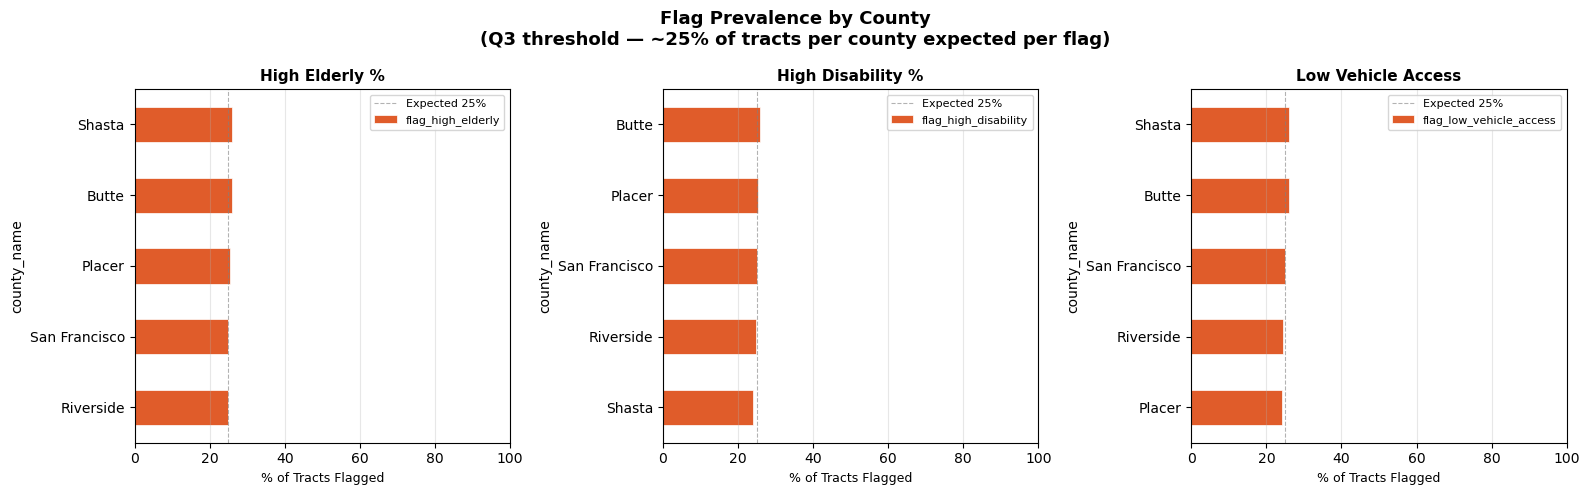

In [75]:
# Flag prevalence by county — bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

flag_labels = {
    'flag_high_elderly'       : 'High Elderly %',
    'flag_high_disability'    : 'High Disability %',
    'flag_low_vehicle_access' : 'Low Vehicle Access',
}

for ax, (flag_col, label) in zip(axes, flag_labels.items()):
    county_flag_rate = (
        tracts.groupby('county_name')[flag_col].mean() * 100
    ).sort_values(ascending=True)

    county_flag_rate.plot(kind='barh', ax=ax, color='#e05c2a', edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('% of Tracts Flagged', fontsize=9)
    ax.set_xlim(0, 100)
    ax.axvline(25, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Expected 25%')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(
    'Flag Prevalence by County\n(Q3 threshold — ~25% of tracts per county expected per flag)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('flag_prevalence_by_county.png', dpi=150, bbox_inches='tight')
plt.show()


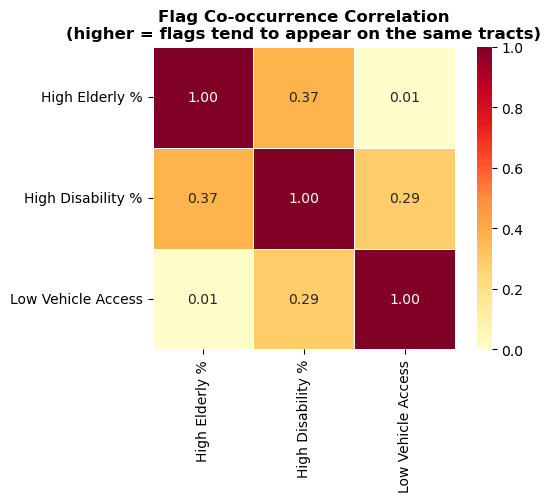

In [76]:
# Co-occurrence heatmap — which flags tend to appear together?
flag_corr = tracts[flag_cols].rename(columns=flag_labels).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    flag_corr, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Flag Co-occurrence Correlation\n(higher = flags tend to appear on the same tracts)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('flag_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()


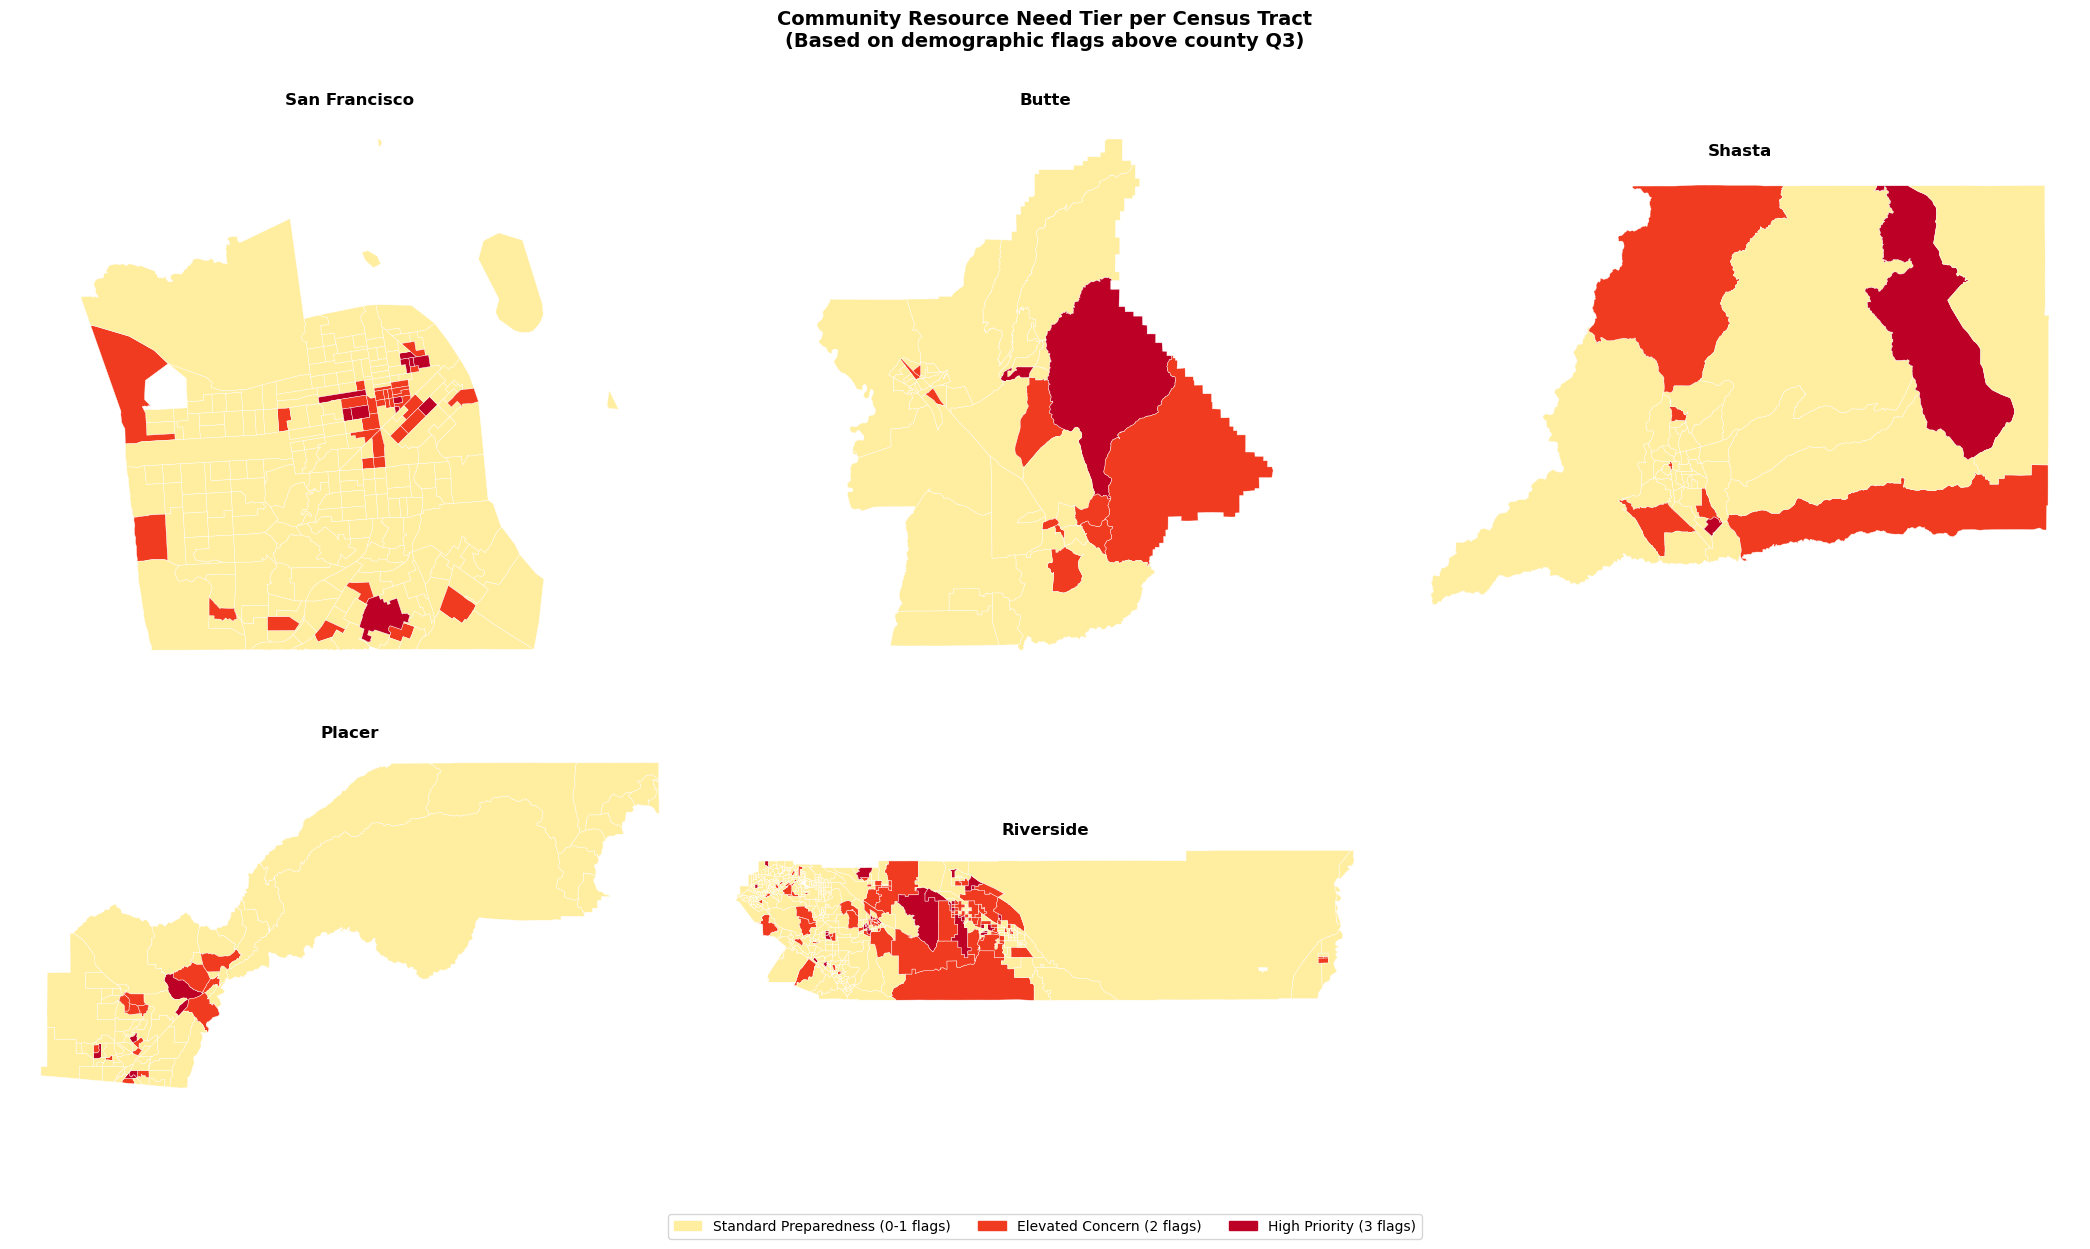

In [77]:
import matplotlib.patches as mpatches

# Choropleth — preparedness tier per tract, one panel per county
tracts_gdf = tracts if isinstance(tracts, gpd.GeoDataFrame) else \
    gpd.GeoDataFrame(tracts, geometry='geometry', crs='EPSG:4326')

tier_colors = {
    'Standard Preparedness': '#FFEDA0',
    'Elevated Concern':       '#F03B20',
    'High Priority':          '#BD0026',
}

ncols = 3
nrows = int(np.ceil(len(top_county_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = np.array(axes).flatten()

for idx, (fips, cname) in enumerate(zip(top_county_fips, top_county_names)):
    ax        = axes[idx]
    county_df = tracts_gdf[tracts_gdf['county_fips'] == fips].copy()
    if county_df.empty:
        ax.set_visible(False)
        continue
    county_df['tier_color'] = county_df['preparedness_tier'].map(tier_colors)
    county_df.plot(
        color=county_df['tier_color'], ax=ax,
        edgecolor='white', linewidth=0.3,
        missing_kwds={'color': 'lightgrey'},
    )
    ax.set_title(cname, fontsize=12, fontweight='bold')
    ax.axis('off')

for ax in axes[len(top_county_fips):]:
    ax.set_visible(False)

legend_patches = [
    mpatches.Patch(color='#FFEDA0', label='Standard Preparedness (0-1 flags)'),
    mpatches.Patch(color='#F03B20', label='Elevated Concern (2 flags)'),
    mpatches.Patch(color='#BD0026', label='High Priority (3 flags)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
fig.suptitle(
    'Community Resource Need Tier per Census Tract\n'
    '(Based on demographic flags above county Q3)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('total_flags_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Output Files

Two files are exported:

- **`wildfire_community_tracts.csv`** — tabular data for the LLM matching pipeline.
  Each row is a tract with all demographic features and flags. The LLM uses the `flag_*` columns
  to match helper offers to the tracts that need them most.

- **`wildfire_community_tracts.geojson`** — spatial file for the web map.
  Same data plus polygon geometry for rendering tract boundaries and the 'raised hand' shading.

### Column reference

| Column | Description |
|---|---|
| `GEOID` | Census tract identifier |
| `NAME` | Census tract name |
| `county_fips` / `county_name` | County identifiers |
| `Total Population` | Total population of the census tract |
| `raised_hand_count` | Number of active help requests in this tract (dummy data for prototype) |
| `raised_hand_pct` | Raised hands as % of tract population — used for map shading intensity |
| `Percent of Households with Elderly` | % households with 65+ resident |
| `Percent of Population with Disability` | % population with a disability |
| `Percent of Households without Vehicle` | % households with no vehicle |
| `flag_high_elderly` | 1 if elderly % > county Q3 |
| `flag_high_disability` | 1 if disability % > county Q3 |
| `flag_low_vehicle_access` | 1 if no-vehicle % > county Q3 |
| `total_flags` | Count of flags set (0-3) |
| `preparedness_tier` | Standard Preparedness / Elevated Concern / High Priority |



In [79]:
output_cols = [
    # Identifiers
    'GEOID', 'NAME', 'county_fips', 'county_name',
    # Demographics
    'Total Population',
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
    # Flags
    'flag_high_elderly',
    'flag_high_disability',
    'flag_low_vehicle_access',
    'total_flags',
    'preparedness_tier',
]

# CSV — for LLM matching pipeline (no geometry needed)
csv_out = tracts[output_cols].copy()
csv_out.to_csv('wildfire_community_tracts.csv', index=False)
print(f'CSV exported: wildfire_community_tracts.csv  ({len(csv_out):,} rows x {len(output_cols)} columns)')

# GeoJSON — for web map (includes geometry)
tracts_gdf = tracts if isinstance(tracts, gpd.GeoDataFrame) else \
    gpd.GeoDataFrame(tracts, geometry='geometry', crs='EPSG:4326')
geojson_out = tracts_gdf[output_cols + ['geometry']].copy()
geojson_out.to_file('wildfire_community_tracts.geojson', driver='GeoJSON')
print(f'GeoJSON exported: wildfire_community_tracts.geojson  ({len(geojson_out):,} features)')

CSV exported: wildfire_community_tracts.csv  (951 rows x 13 columns)
GeoJSON exported: wildfire_community_tracts.geojson  (951 features)


In [80]:
# Preview the output
print('Output sample (first 10 rows):')
display(csv_out[['GEOID', 'county_name'] + flag_cols + ['total_flags', 'preparedness_tier']].head(10))


Output sample (first 10 rows):


,GEOID,county_name,flag_high_elderly,flag_high_disability,flag_low_vehicle_access,total_flags,preparedness_tier
0,06007000102,Butte,0,0,0,0,Standard Preparedness
1,06007000103,Butte,0,0,0,0,Standard Preparedness
2,06007000104,Butte,0,0,0,0,Standard Preparedness
3,06007000201,Butte,0,0,0,0,Standard Preparedness
4,06007000202,Butte,0,1,1,2,Elevated Concern
5,06007000300,Butte,0,1,1,2,Elevated Concern
6,06007000401,Butte,0,0,0,0,Standard Preparedness
7,06007000403,Butte,0,0,0,0,Standard Preparedness
8,06007000404,Butte,0,0,0,0,Standard Preparedness
9,06007000501,Butte,0,0,0,0,Standard Preparedness
